# Radiation Model Research

**Testing Linear No-Threshold Model for Radiation Level using Machine Learning and Neural Network**

*What is Linear No-Threshold (LNT) model*

Linear No Threshold model is the globaly accepted model to determine propotional harm caused by radiation to a individual. As stated in the name itself the model sets no threshold for safe radiation exposer, i.e radiation no matter how small is harmful. This was formulated after the Life Span Study (LSS) of the atomic bomb survivors in Hiroshima and Nagasaki. The lack of a threshold is due to the belief that any dose of ionizing radiation, no matter how small, carries a risk of cancer. This led to ALARA (As Low As Reasonably Achievable) as our aim with radiation exposure.

*Life Span Study (LSS)* 

After the atomic bomb explosion in Japan, LSS was started to study the affeces radiation had on survivors. This study later became the basis of our nuclear safety standard as it is the backbone behind LNT. Using LSS as a basis for radiation exposer comes with its probelms, dose-rate being the biggest one. Nuclear explosion is a acute exposer event (high exposer in short period of time) using this data to extrapolate risk for chronic exposer (low exposer over extended period of time) is biologically incompatable. But this was and remains the gold standard for radiation study due to its massive statistical number (120,000 + individuals), demographic diversity, complete dose spectrum and its long term - high quality follow up, hence LSS will also remain as the backbone for our ML model.

<h2>Code</h2>

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import openpyxl
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import linregress
import os
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm
import json
import pickle

Plotting LNT line

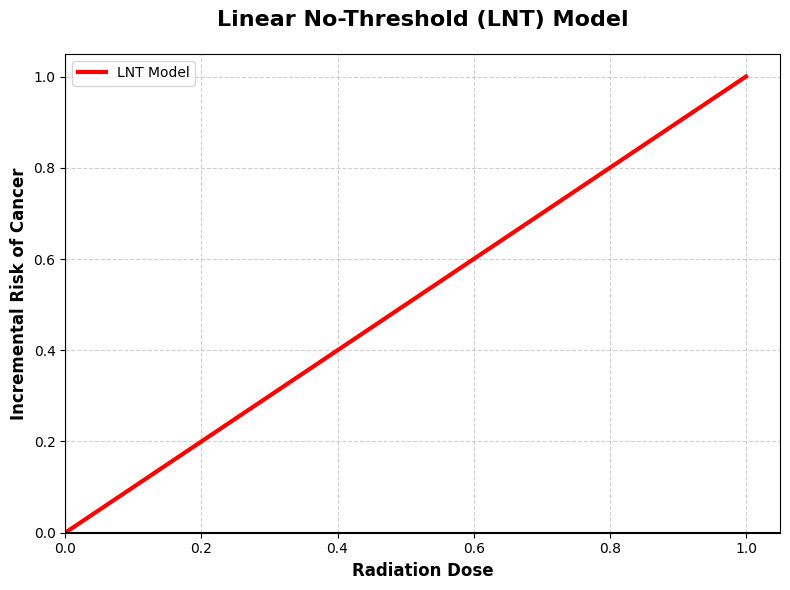

In [29]:
def plot_simple_lnt():
    dose = np.linspace(0, 1, 100)
    
    risk = dose 
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    
    # Plot the LNT line
    plt.plot(dose, risk, color='red', linewidth=3, label='LNT Model')
    
    # Formatting to match textbook LNT charts
    plt.title('Linear No-Threshold (LNT) Model', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Radiation Dose', fontsize=12, fontweight='semibold')
    plt.ylabel('Incremental Risk of Cancer', fontsize=12, fontweight='semibold')
    
    # Force axes to start exactly at the origin (0,0)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    
    # Add a bold baseline at x=0 and y=0
    plt.axvline(0, color='black', linewidth=1.5)
    plt.axhline(0, color='black', linewidth=1.5)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_simple_lnt()

Load Data

In [ ]:
df = pd.read_csv('Data/lss14.csv')

ERR check for Data validity

In [ ]:
def calculate_err(file_path):

    # 1. Data Preparation "colon10" is taken as the dose variable and is converted from mGy to Sv.
    df['dose_sv'] = df['colon10'] / 1000.0

    # We filter out rows with 0 person-years (pyr) to avoid division errors
    df_clean = df[df['pyr'] > 0].copy()

    # 3. Define the Poisson Regression Model
    # The model predicts 'solid' cancer deaths based on dose,
    # while controlling for background factors (Sex, Age, City).
    # The 'offset' is log(pyr) because we are modeling Rate = Deaths / PYR.
    # Formula: log(Rate) = Intercept + Beta * Dose + Beta_Sex * Sex ...
    
    formula = "solid ~ dose_sv + C(sex) + C(agecat) + C(city)"
    
    model = smf.glm(
        formula=formula, 
        data=df_clean, 
        offset=np.log(df_clean['pyr']), 
        family=sm.families.Poisson()
    )

    # 4. Run the Calculations
    result = model.fit()

    # 5. Extract the Risk Coefficient (Beta)
    # The coefficient 'beta' represents the slope of the log-risk.
    beta = result.params['dose_sv']
    
    # Calculate ERR at 1 Sv
    # Since the model is log-linear: Relative Risk (RR) = exp(beta * dose)
    # ERR = RR - 1
    err_at_1sv = np.exp(beta * 1.0) - 1

    # 6. Output the Results
    print("--- LSS ERR Calculation Results ---")
    print(f"Regression Coefficient (Beta): {beta:.4f}")
    print(f"Excess Relative Risk (ERR) at 1 Sv: {err_at_1sv:.4f} ({err_at_1sv*100:.2f}%)")
    print("\nInterpretation:")
    print(f"For every 1 Sv of dose, the cancer risk increases by approximately {err_at_1sv*100:.1f}%.")
    print(f"This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.")

if __name__ == "__main__":
    # Ensure the file 'Data/lss14.csv' is in the same folder
    calculate_err('Data/lss14.csv')

--- LSS ERR Calculation Results ---
Regression Coefficient (Beta): 0.3513
Excess Relative Risk (ERR) at 1 Sv: 0.4209 (42.09%)

Interpretation:
For every 1 Sv of dose, the cancer risk increases by approximately 42.1%.
This aligns with the standard '40-60%' ERR often cited for solid cancer in LSS data.


Subject Age Distribution:

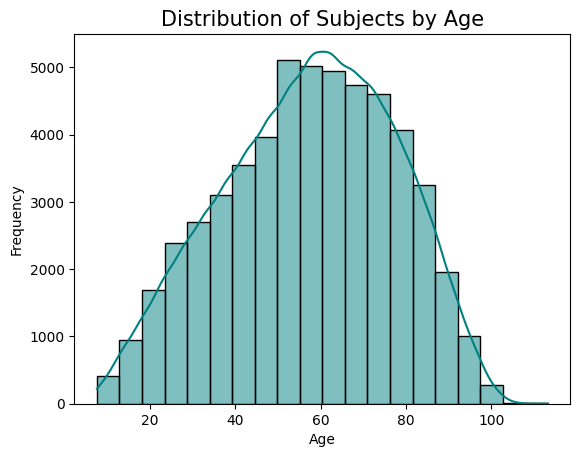

In [33]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Subjects by Age', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Quantifying Low Dose vs High Dose

In [30]:
df['dose_gy'] = df['colon10']

# Common definitions for "Low Dose" boundaries
thresholds = [20, 50, 80, 100]

print("--- Ratio by Person-Years (Statistical Weight) ---")
print(f"{'Threshold (mSv)'} {'Low Dose (mSv)'} {'High Dose (mSv)'} {'Ratio (High/Low)'} {'% Data is Low Dose'}")
print("-" * 90)

for thresh in thresholds:
    low_mask = df['dose_gy'] <= thresh
    high_mask = df['dose_gy'] > thresh
    
    # Calculate sums
    low_pyr = df.loc[low_mask, 'pyr'].sum()
    high_pyr = df.loc[high_mask, 'pyr'].sum()
    
    # Calculate ratio
    ratio = high_pyr / low_pyr if low_pyr > 0 else 0
    percent_low = (low_pyr / (low_pyr + high_pyr)) * 100
    
    print(f"{thresh:<15.2f} {low_pyr:<15.0f} {high_pyr:<15.0f} {ratio:<20.4f} {percent_low:.1f}%")

--- Ratio by Person-Years (Statistical Weight) ---
Threshold (mSv) Low Dose (mSv) High Dose (mSv) Ratio (High/Low) % Data is Low Dose
------------------------------------------------------------------------------------------
20.00           2022576         1271706         0.6288               61.4%
50.00           2400342         893941          0.3724               72.9%
80.00           2530659         763623          0.3017               76.8%
100.00          2609197         685085          0.2626               79.2%


Assessing Dose vs Death 

   city_name dose_group  subjects  Cancer_Deaths  No_Cancer_Death
0  Hiroshima       High    1573.0          390.0           1183.0
1  Hiroshima        Low   44430.0         5892.0          38538.0
2  Hiroshima     Medium   12477.0         1863.0          10614.0
3   Nagasaki       High     794.0          167.0            627.0
4   Nagasaki        Low   24040.0         2855.0          21185.0
5   Nagasaki     Medium    3277.0          453.0           2824.0


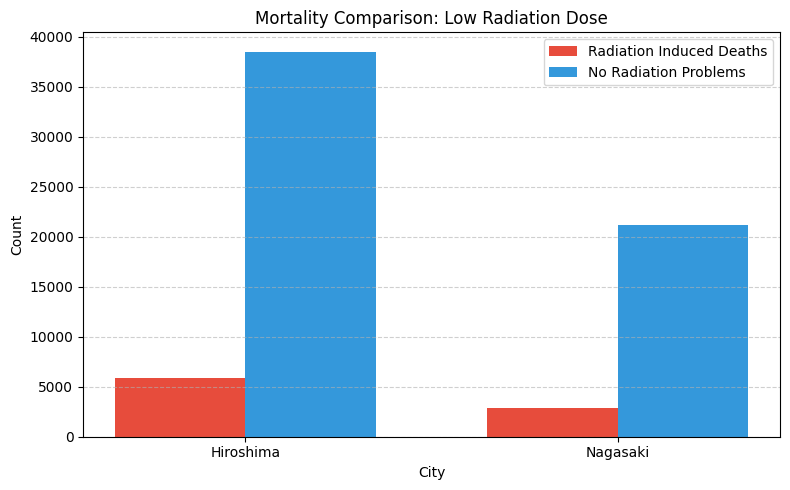

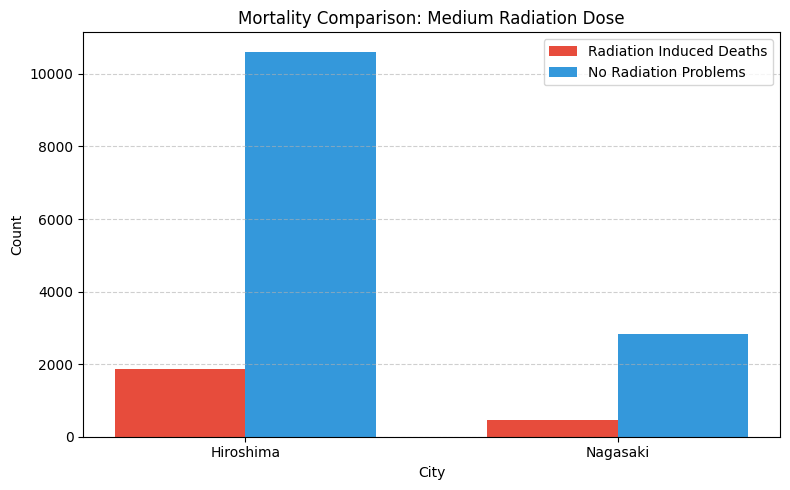

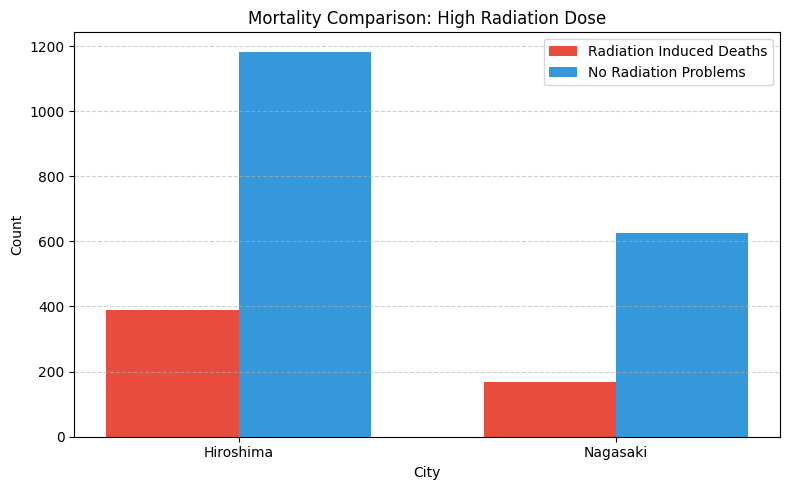

In [23]:
# Categorize radiation dose levels
# Based on dosecat (1-22): 1-6 (Low: 0 to 0.125Gy), 8-15 (Medium: 0.125 to 1.0Gy), 16-21 (High: 1 to 3Gy) and 22 (Extreme: 3+ Gy)
def get_dose_label(cat):
    if cat <= 6:
        return 'Low'
    elif cat <= 15:
        return 'Medium'
    elif cat <= 21:
        return 'High'

df['dose_group'] = df['dosecat'].apply(get_dose_label)

# Map city codes to names
city_map = {1: 'Hiroshima', 2: 'Nagasaki'}
df['city_name'] = df['city'].map(city_map)

# Aggregate subjects and specific deaths
summary = df.groupby(['city_name', 'dose_group']).agg({
    'subjects': 'sum',
    'solid': 'sum',
    'leukemia': 'sum',
    'lymphoma': 'sum',
    'myeloma': 'sum'
}).reset_index()

# Calculate Cancer Deaths (Solid + Leukemia + Lymphoma + Myeloma) and Non-Cancer outcomes
summary['Cancer_Deaths'] = summary['solid'] + summary['leukemia'] + summary['lymphoma'] + summary['myeloma']
summary['No_Cancer_Death'] = summary['subjects'] - summary['Cancer_Deaths']

# Display the summary table
print(summary[['city_name', 'dose_group', 'subjects', 'Cancer_Deaths', 'No_Cancer_Death']])

# Generate 3 charts
dose_levels = ['Low', 'Medium', 'High']
colors = ['#e74c3c', '#3498db'] # Red for cancer, Blue for others

for level in dose_levels:
    data = summary[summary['dose_group'] == level]
    
    cities = data['city_name'].tolist()
    cancer = data['Cancer_Deaths'].tolist()
    no_cancer = data['No_Cancer_Death'].tolist()
    
    x = range(len(cities))
    width = 0.35
    
    plt.figure(figsize=(8, 5))
    plt.bar(x, cancer, width, label='Radiation Induced Deaths', color=colors[0])
    plt.bar([p + width for p in x], no_cancer, width, label='No Radiation Problems', color=colors[1])
    
    plt.xlabel('City')
    plt.ylabel('Count')
    plt.title(f'Mortality Comparison: {level} Radiation Dose')
    plt.xticks([p + width/2 for p in x], cities)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # In a local Jupyter Notebook, you can use plt.show() here
    plt.savefig(f'mortality_{level.lower()}.png')

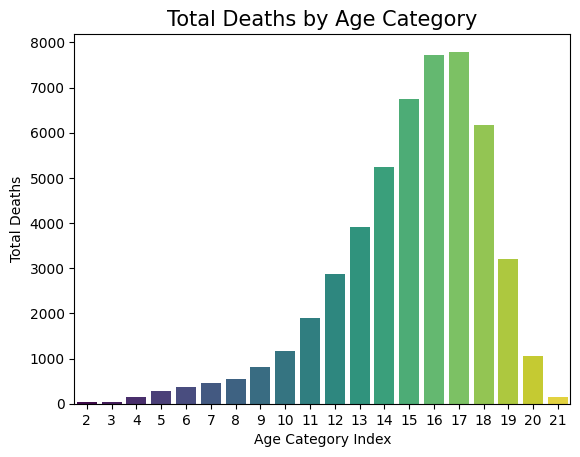

In [34]:
plt.figure()
age_death = df.groupby('agecat')['death'].sum().reset_index()

# Fix: Assign 'agecat' to hue and set legend=False
sns.barplot(
    data=age_death, 
    x='agecat', 
    y='death', 
    hue='agecat', 
    palette='viridis', 
    legend=False
)

plt.title('Total Deaths by Age Category', fontsize=15)
plt.xlabel('Age Category Index')
plt.ylabel('Total Deaths')
plt.show()

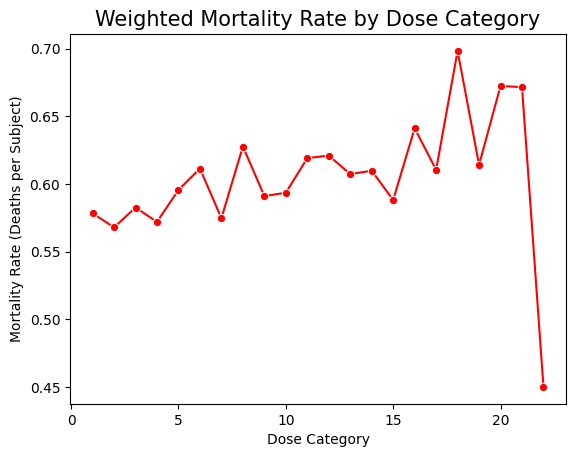

In [35]:
plt.figure()
# Calculate weighted mortality rate (Total deaths / Total subjects) for each dose category
dose_stats = df.groupby('dosecat').agg({'death': 'sum', 'subjects': 'sum'}).reset_index()
dose_stats['mortality_rate'] = dose_stats['death'] / dose_stats['subjects']

sns.lineplot(data=dose_stats, x='dosecat', y='mortality_rate', marker='o', color='red')
plt.title('Weighted Mortality Rate by Dose Category', fontsize=15)
plt.xlabel('Dose Category')
plt.ylabel('Mortality Rate (Deaths per Subject)')
plt.show()

Successfully loaded lss14.csv

--- Survival vs Death Rates by Dose Category ---
Dosecat  1: Survived  88.00% | Died 12.00% (Total: 38509)
Dosecat  2: Survived  88.19% | Died 11.81% (Total: 14555)
Dosecat  3: Survived  88.00% | Died 12.00% (Total: 6411)
Dosecat  4: Survived  87.18% | Died 12.82% (Total: 4203)
Dosecat  5: Survived  86.97% | Died 13.03% (Total: 2710)
Dosecat  6: Survived  86.89% | Died 13.11% (Total: 2082)
Dosecat  7: Survived  88.35% | Died 11.65% (Total: 1975)
Dosecat  8: Survived  85.10% | Died 14.90% (Total: 1523)
Dosecat  9: Survived  87.47% | Died 12.53% (Total: 1460)
Dosecat 10: Survived  85.33% | Died 14.67% (Total: 1016)
Dosecat 11: Survived  87.07% | Died 12.93% (Total: 1570)
Dosecat 12: Survived  84.90% | Died 15.10% (Total: 1417)
Dosecat 13: Survived  86.55% | Died 13.45% (Total: 3369)
Dosecat 14: Survived  86.31% | Died 13.69% (Total: 2176)
Dosecat 15: Survived  82.29% | Died 17.71% (Total: 1248)
Dosecat 16: Survived  81.53% | Died 18.47% (Total: 758)
Dosecat

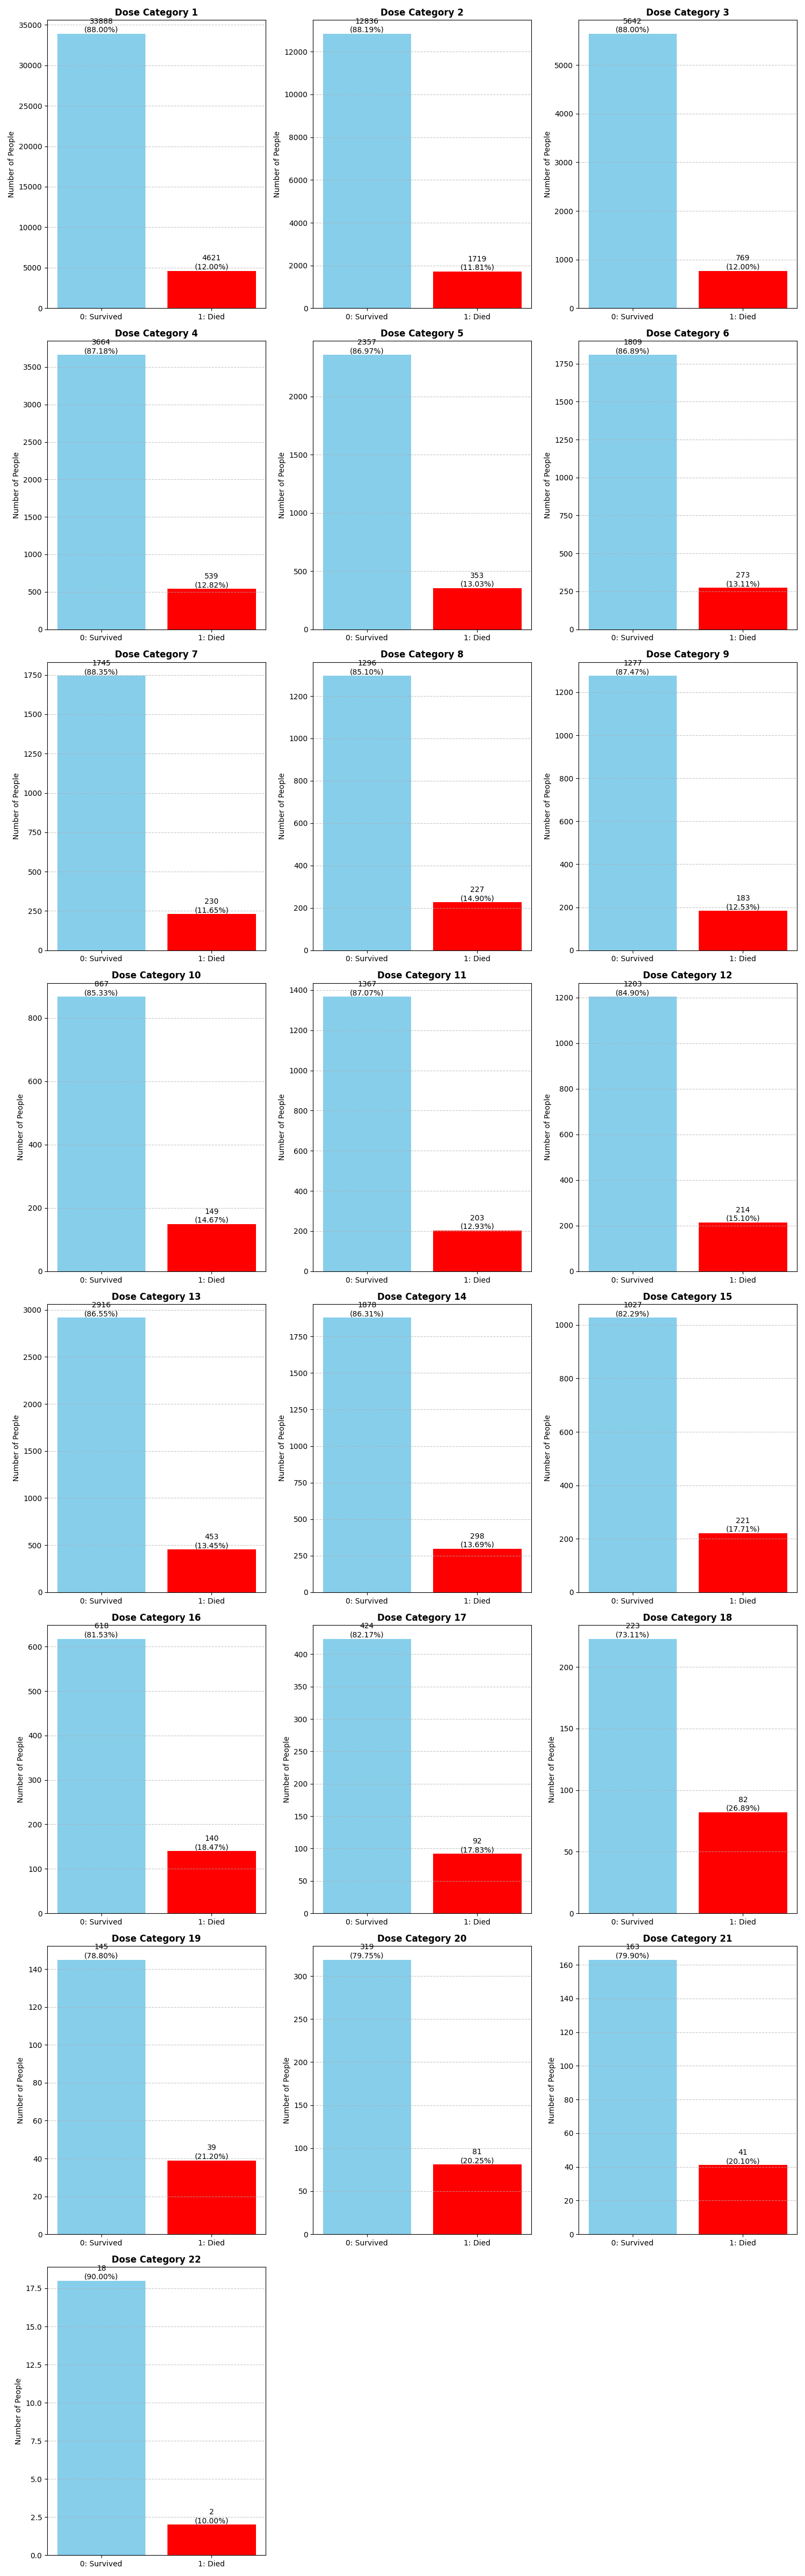

In [ ]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# 1. Load the dataset
try:
    df = pd.read_csv('Data/lss14.csv')
    print("Successfully loaded Data/lss14.csv")
except FileNotFoundError:
    print("Error: Data/lss14.csv not found. Please ensure the file is in the working directory.")
    # Fallback dummy data for demonstration if file is missing
    df = pd.DataFrame({
        'dosecat': np.random.randint(1, 15, 1000),
        'subjects': np.random.randint(10, 100, 1000),
        'solid': np.random.randint(0, 5, 1000)
    })

# 2. Group the data by dose category
# We sum the 'subjects' (total people) and 'solid' (deaths from solid cancer)
grouped = df.groupby('dosecat')[['subjects', 'solid']].sum().reset_index()

# Calculate those who did NOT die from solid cancer ("0" in your 0 vs 1)
grouped['survived_solid'] = grouped['subjects'] - grouped['solid']

# Calculate survival and death chances (percentages)
grouped['survival_chance'] = (grouped['survived_solid'] / grouped['subjects']) * 100
grouped['death_chance'] = (grouped['solid'] / grouped['subjects']) * 100

# Print a text summary to the console for easy reading
print("\n--- Survival vs Death Rates by Dose Category ---")
for _, row in grouped.iterrows():
    print(f"Dosecat {int(row['dosecat']):>2}: Survived {row['survival_chance']:>6.2f}% | Died {row['death_chance']:>5.2f}% (Total: {int(row['subjects'])})")

# 3. Plotting Independent Bar Graphs (Grid of Subplots)
unique_dosecats = sorted(grouped['dosecat'].unique())
n_cats = len(unique_dosecats)
cols = 3
# Calculate required rows based on number of categories and 3 columns
rows = int(np.ceil(n_cats / cols))

# Increased vertical figure size slightly to accommodate the two-line text labels
fig, axes = plt.subplots(rows, cols, figsize=(15, 6 * rows))
axes = axes.flatten()

for i, cat in enumerate(unique_dosecats):
    ax = axes[i]
    cat_data = grouped[grouped['dosecat'] == cat].iloc[0]
    
    # Plot raw counts for the Y-axis
    bars = ax.bar(['0: Survived', '1: Died'], 
                  [cat_data['survived_solid'], cat_data['solid']], 
                  color=['skyblue', 'red'])
    
    ax.set_title(f'Dose Category {int(cat)}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of People')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add numerical labels (Count + Percentage) on top of the bars
    chances = [cat_data['survival_chance'], cat_data['death_chance']]
    for bar, chance in zip(bars, chances):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({chance:.2f}%)',
                ha='center', va='bottom', fontsize=10)

# Hide any extra unused subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save the plot
plt.savefig("dosecat_independent_barplots.png")
print("\nPlot saved as dosecat_independent_barplots.png")

# Display logic for Windows/Jupyter
plt.close(fig)

if in_jupyter:
    display(Image("dosecat_independent_barplots.png"))
else:
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Re-open figure to show it if running in a standard Windows terminal/IDE
        img = plt.imread("dosecat_independent_barplots.png")
        plt.figure(figsize=(15, 6 * rows))
        plt.imshow(img)
        plt.axis('off')
        plt.show()

Plot saved: mortality_rate_by_dosecat.png

 Dosecat   Deaths          PYR   Rate/1000pyr               95% CI
--------------------------------------------------------------------
       1     4621      1465270          3.154  (3.063 – 3.246)
       2     1719       557306          3.084  (2.940 – 3.234)
       3      769       242118          3.176  (2.956 – 3.409)
       4      539       163290          3.301  (3.028 – 3.592)
       5      353       102676          3.438  (3.089 – 3.816)
       6      273        78538          3.476  (3.076 – 3.914)
       7      230        75643          3.041  (2.660 – 3.460)
       8      227        56825          3.995  (3.492 – 4.550)
       9      183        56180          3.257  (2.802 – 3.765)
      10      149        38270          3.893  (3.293 – 4.571)
      11      203        58823          3.451  (2.993 – 3.960)
      12      214        53380          4.009  (3.490 – 4.584)
      13      453       127076          3.565  (3.244 – 3.909)
  

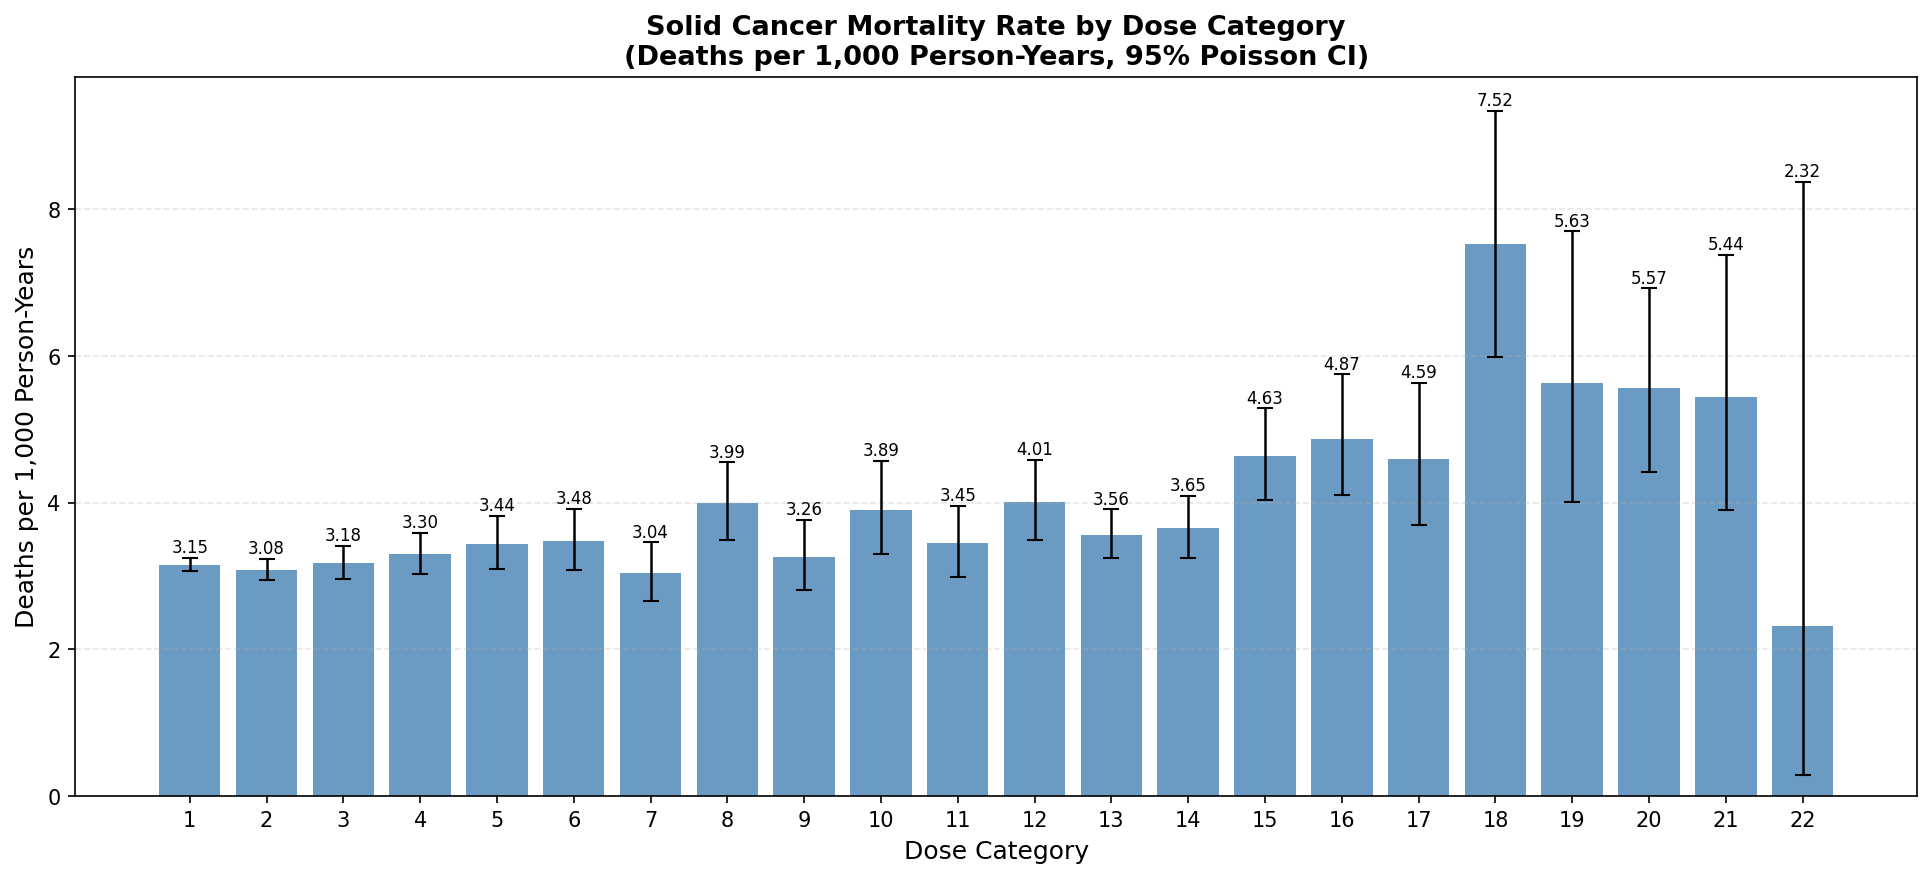

In [ ]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Load and aggregate by dosecat
# ---------------------------------------------------------------------------
df = pd.read_csv('Data/lss14.csv')

grouped = df.groupby('dosecat')[['solid', 'pyr']].sum().reset_index()

# Deaths per 1000 person-years — the epidemiologically correct yearly rate
grouped['rate_per_1000'] = (grouped['solid'] / grouped['pyr']) * 1000

# Poisson 95% CI on the rate: uses exact Poisson interval on the death count
# then scales to per-1000-pyr units
def poisson_ci(deaths, pyr, scale=1000):
    lo = stats.chi2.ppf(0.025, 2 * deaths) / 2 if deaths > 0 else 0.0
    hi = stats.chi2.ppf(0.975, 2 * (deaths + 1)) / 2
    return (lo / pyr) * scale, (hi / pyr) * scale

grouped['ci_lo'], grouped['ci_hi'] = zip(*grouped.apply(
    lambda r: poisson_ci(r['solid'], r['pyr']), axis=1
))
grouped['err_lo'] = grouped['rate_per_1000'] - grouped['ci_lo']
grouped['err_hi'] = grouped['ci_hi'] - grouped['rate_per_1000']

# ---------------------------------------------------------------------------
# 2. Single bar chart — one bar per dosecat with Poisson error bars
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 6))

x     = grouped['dosecat'].values
rates = grouped['rate_per_1000'].values
yerr  = np.array([grouped['err_lo'].values, grouped['err_hi'].values])

bars = ax.bar(x, rates, color='steelblue', alpha=0.8,
              yerr=yerr, capsize=4, error_kw={'linewidth': 1.2, 'color': 'black'})

# Rate label above each bar
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + yerr[1][list(rates).index(rate)] + 0.02,
            f'{rate:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_title("Solid Cancer Mortality Rate by Dose Category\n"
             "(Deaths per 1,000 Person-Years, 95% Poisson CI)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Dose Category", fontsize=12)
ax.set_ylabel("Deaths per 1,000 Person-Years", fontsize=12)
ax.set_xticks(x)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("mortality_rate_by_dosecat.png", dpi=150, bbox_inches='tight')
plt.close(fig)
print("Plot saved: mortality_rate_by_dosecat.png")

# ---------------------------------------------------------------------------
# 3. Console summary
# ---------------------------------------------------------------------------
print(f"\n{'Dosecat':>8} {'Deaths':>8} {'PYR':>12} {'Rate/1000pyr':>14} {'95% CI':>20}")
print("-" * 68)
for _, r in grouped.iterrows():
    print(f"{int(r['dosecat']):>8} {int(r['solid']):>8} {r['pyr']:>12.0f} "
          f"{r['rate_per_1000']:>14.3f}  "
          f"({r['ci_lo']:.3f} – {r['ci_hi']:.3f})")

if in_jupyter:
    display(Image("mortality_rate_by_dosecat.png"))

2. Bayesian Neural Network with further Improvements

In [ ]:
# ---------------------------------------------------------------------------
# 1. Load & Preprocess
# ---------------------------------------------------------------------------
df = pd.read_csv('Data/lss14.csv')

# Keep full dose range — restricting to <=20 discards threshold-relevant signal
# dosecat 22 is the only category outside original range (~1740 rows), keep it

# second age dimension, capturing time-since-exposure effect modification.
features  = ['sex', 'agex', 'age', 'dosecat']
target    = 'solid'
exposure  = 'pyr'

df = df[features + [target, exposure]].dropna()

X_raw  = df[features].values.astype(np.float32)
y_raw  = df[target].values.astype(np.float32)
pyr_raw = df[exposure].values.astype(np.float32)

# sex is binary (1/2) — re-encode to 0/1 for the embedding offset
X_raw[:, 0] = X_raw[:, 0] - 1.0

# Standardise continuous features; exceprt sex
def standardise(arr, col):
    mu, sigma = arr[:, col].mean(), arr[:, col].std()
    arr[:, col] = (arr[:, col] - mu) / sigma
    return float(mu), float(sigma)

params = {}
params['agex_mean'],   params['agex_std']   = standardise(X_raw, 1)
params['age_mean'],    params['age_std']     = standardise(X_raw, 2)
params['dose_mean'],   params['dose_std']    = standardise(X_raw, 3)
params['features'] = features

X_t   = torch.tensor(X_raw,   dtype=torch.float32)
y_t   = torch.tensor(y_raw,   dtype=torch.float32).view(-1, 1)
pyr_t = torch.tensor(pyr_raw, dtype=torch.float32).view(-1, 1)

# 80/20 stratified-style split — ensures we can monitor generalisation
full_ds = TensorDataset(X_t, y_t, pyr_t)
n_train = int(0.8 * len(full_ds))
n_val   = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)

# ---------------------------------------------------------------------------
# 2. Architecture
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    """Single-feature subnetwork; dropout kept active at inference for MC sampling."""
    def __init__(self, hidden=64, dropout_p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.SiLU(), nn.Dropout(p=dropout_p),
            nn.Linear(hidden, hidden), nn.SiLU(), nn.Dropout(p=dropout_p),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)


class NeuralGAM(nn.Module):
    """
    Additive model: log(rate) = bias + f_sex(sex) + f_agex(agex)
                                     + f_age(age) + f_dose(dose)
    sex uses a learned scalar offset instead of a subnet (it is binary).
    dose subnet gets slightly elevated dropout for richer uncertainty in the
    threshold region.
    """
    def __init__(self):
        super().__init__()
        self.bias      = nn.Parameter(torch.zeros(1))
        self.sex_coef  = nn.Parameter(torch.zeros(1))   # binary → scalar offset
        self.net_agex  = FeatureNetwork(dropout_p=0.10)
        self.net_age   = FeatureNetwork(dropout_p=0.10)
        self.net_dose  = FeatureNetwork(dropout_p=0.15)  # higher uncertainty at dose

    def forward(self, x):
        sex  = x[:, 0:1]
        agex = x[:, 1:2]
        age  = x[:, 2:3]
        dose = x[:, 3:4]

        lp = (self.bias
              + self.sex_coef * sex
              + self.net_agex(agex)
              + self.net_age(age)
              + self.net_dose(dose))
        return torch.exp(lp)


# ---------------------------------------------------------------------------
# 3. Loss  — numerically stable Poisson NLL, no epsilon masking
# ---------------------------------------------------------------------------
_poisson_nll = nn.PoissonNLLLoss(log_input=False, full=False, reduction='mean')

def poisson_loss(rate, y, pyr):
    # Expected events = rate-per-pyr * pyr; NLL drives shape of dose-response
    return _poisson_nll(rate * pyr, y)


# ---------------------------------------------------------------------------
# 4. Training with validation monitoring
# ---------------------------------------------------------------------------
model     = NeuralGAM()
optimizer = optim.Adam(model.parameters(), lr=2e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5, )
epochs = 300

print("Training Bayesian Neural GAM …")
for epoch in tqdm(range(epochs), desc="Epoch"):

    model.train()
    train_loss = 0.0
    for bX, by, bpyr in train_loader:
        optimizer.zero_grad()
        loss = poisson_loss(model(bX), by, bpyr)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Dropout OFF for deterministic val loss; separate MC pass used at inference
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bX, by, bpyr in val_loader:
            val_loss += poisson_loss(model(bX), by, bpyr).item()

    scheduler.step(val_loss)

    if (epoch + 1) % 50 == 0:
        tqdm.write(f"  epoch {epoch+1:3d} | "
                   f"train {train_loss/len(train_loader):.4f} | "
                   f"val {val_loss/len(val_loader):.4f}")

# ---------------------------------------------------------------------------
# 5. MC Dropout inference helper  (saved alongside weights for notebook use)
# ---------------------------------------------------------------------------
def mc_predict(model, X_tensor, n_samples=200):
    """
    Run n_samples forward passes with dropout active to approximate the
    posterior predictive distribution over the dose-response rate.
    Returns mean and std across samples.
    """
    model.train()  # activates dropout
    with torch.no_grad():
        samples = torch.stack([model(X_tensor) for _ in range(n_samples)])
    return samples.mean(0), samples.std(0)


# ---------------------------------------------------------------------------
# 6. Save
# ---------------------------------------------------------------------------
torch.save(model.state_dict(), 'neural_gam_model.pt')
with open('standardization_params.json', 'w') as f:
    json.dump(params, f, indent=4)

print("\nSaved: neural_gam_model.pt, standardization_params.json")

Training Bayesian Neural GAM …


Epoch:  17%|█▋        | 50/300 [01:41<08:17,  1.99s/it]

  epoch  50 | train 0.2156 | val 0.2189


Epoch:  33%|███▎      | 100/300 [03:19<06:37,  1.99s/it]

  epoch 100 | train 0.2128 | val 0.2189


...

  epoch 200 | train 0.2121 | val 0.2189


Epoch:  83%|████████▎ | 250/300 [08:22<01:49,  2.18s/it]

  epoch 250 | train 0.2143 | val 0.2189


Epoch: 100%|██████████| 300/300 [09:52<00:00,  1.98s/it]

  epoch 300 | train 0.2123 | val 0.2189

Saved: neural_gam_model.pt, standardization_params.json


Model loaded successfully
Statistically significant threshold: 29.03 mGy
Plot 1 saved
Plot 2 saved


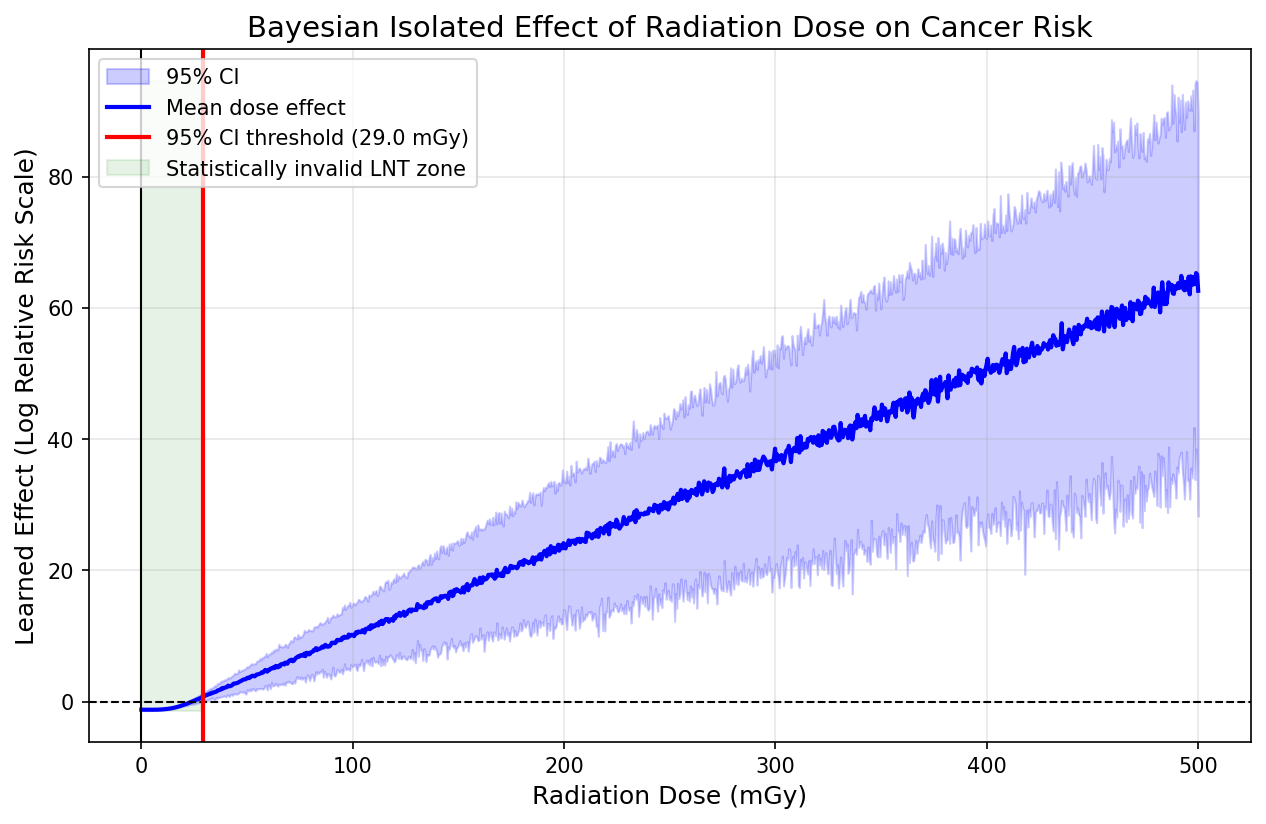

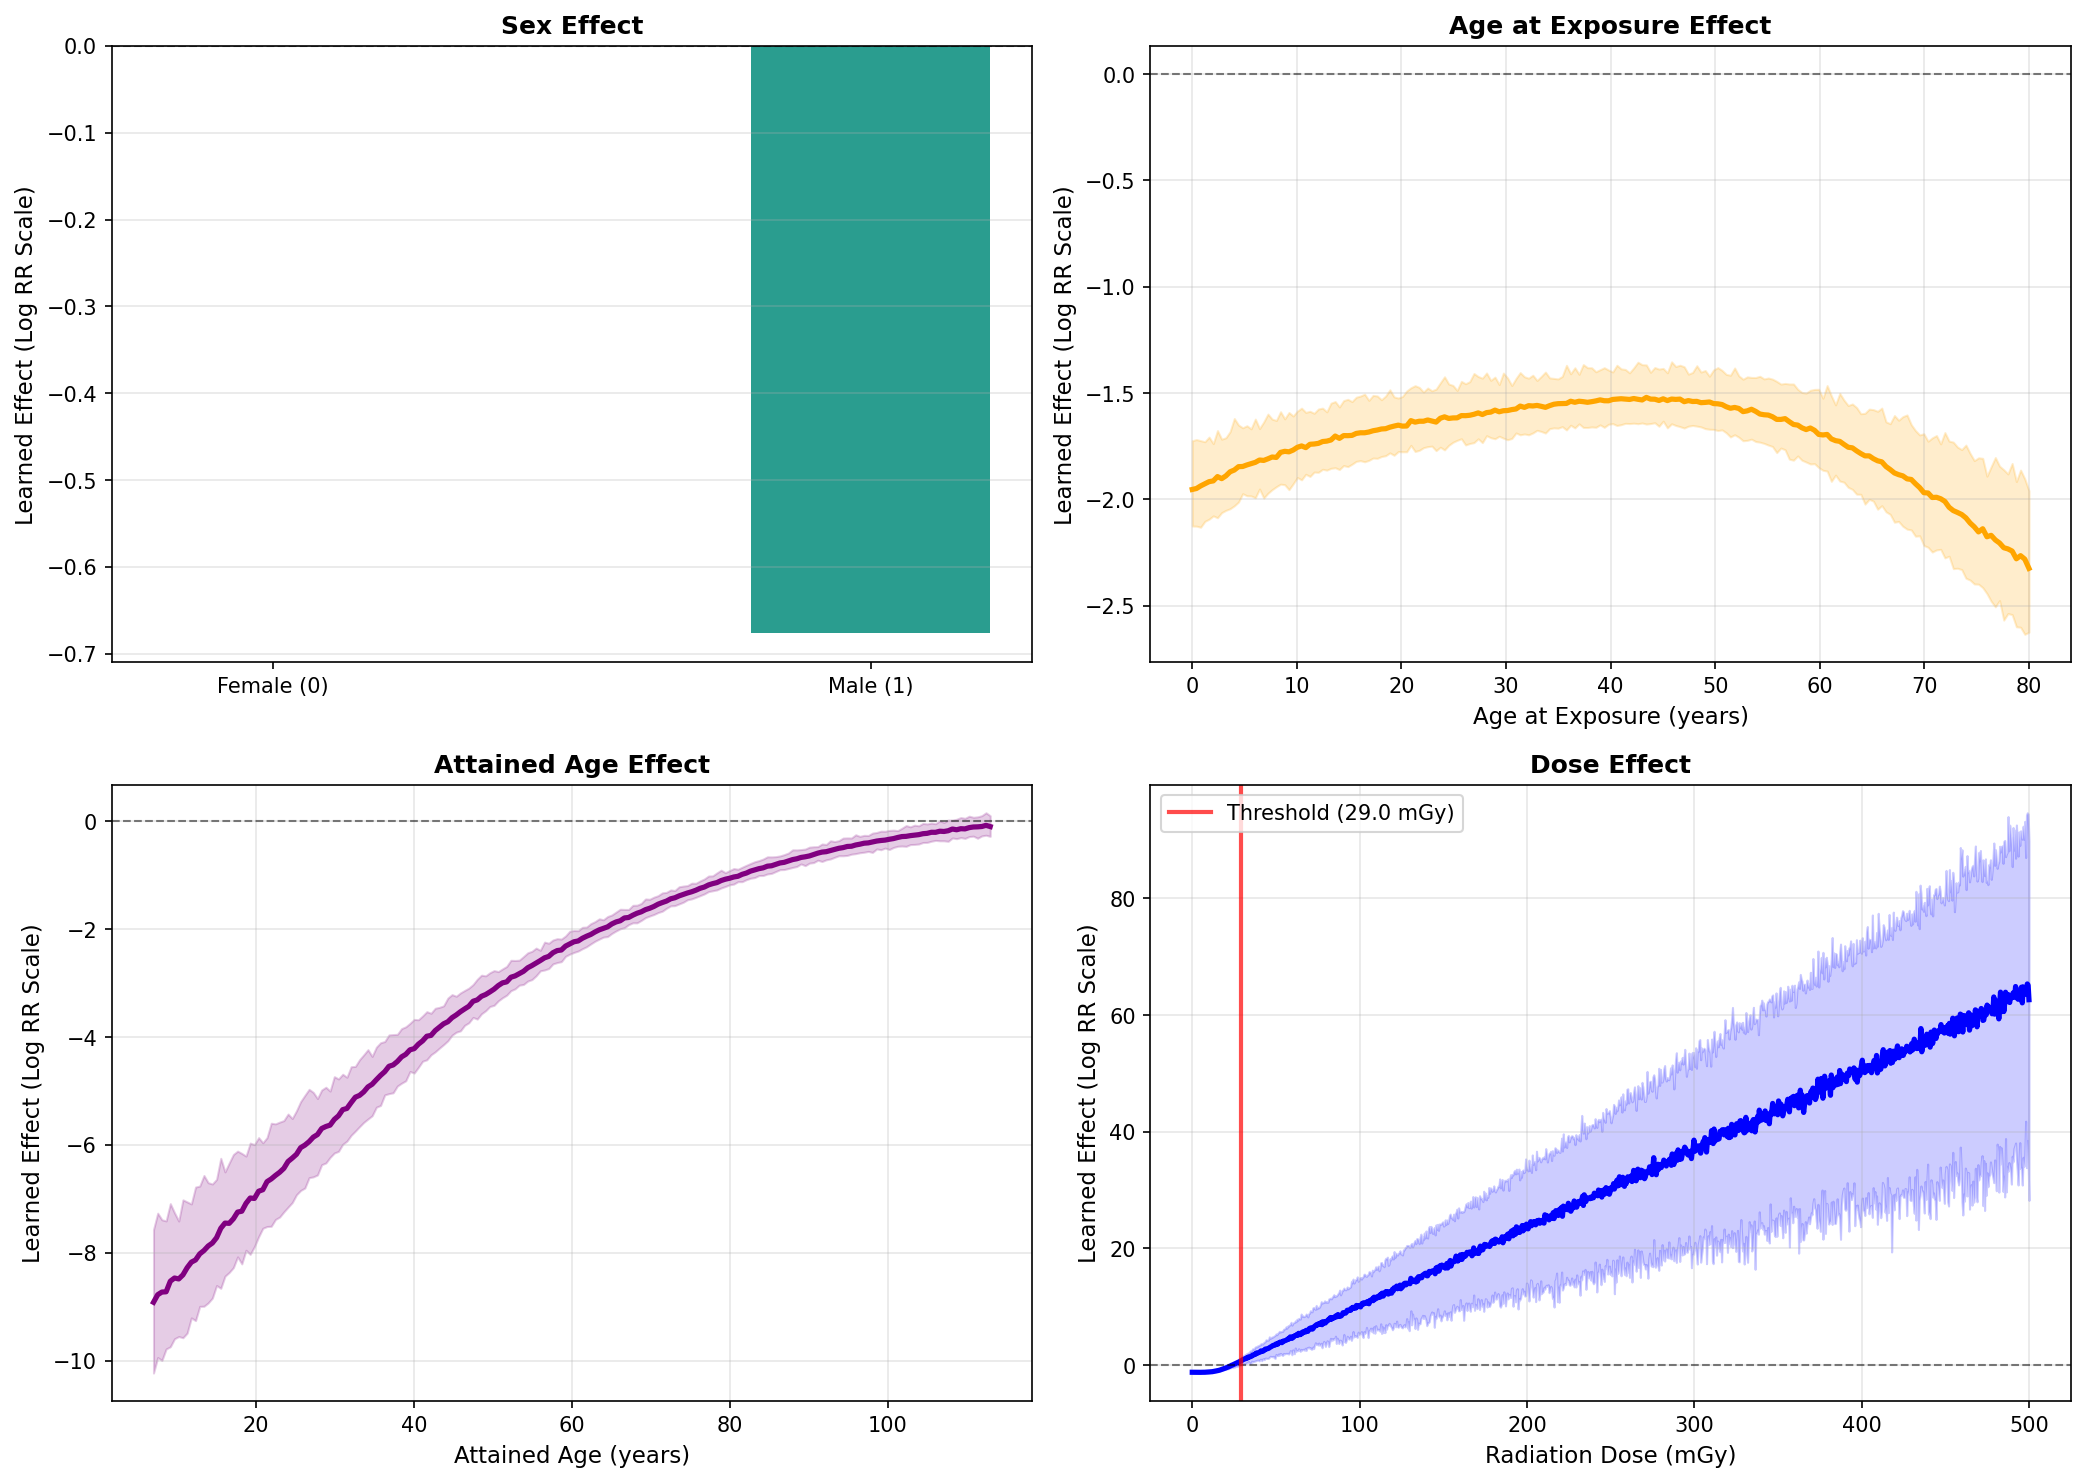

In [11]:
try:
    from IPython.display import Image, display
    in_jupyter = True
except ImportError:
    in_jupyter = False

# ---------------------------------------------------------------------------
# 1. Load standardization params
# ---------------------------------------------------------------------------
with open('standardization_params.json', 'r') as f:
    params = json.load(f)

# ---------------------------------------------------------------------------
# 2. Architecture — must match training code exactly
# ---------------------------------------------------------------------------
class FeatureNetwork(nn.Module):
    def __init__(self, hidden=64, dropout_p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.SiLU(), nn.Dropout(p=dropout_p),
            nn.Linear(hidden, hidden), nn.SiLU(), nn.Dropout(p=dropout_p),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

class NeuralGAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.bias     = nn.Parameter(torch.zeros(1))
        self.sex_coef = nn.Parameter(torch.zeros(1))
        self.net_agex = FeatureNetwork(dropout_p=0.10)
        self.net_age  = FeatureNetwork(dropout_p=0.10)
        self.net_dose = FeatureNetwork(dropout_p=0.15)

    def forward(self, x):
        sex  = x[:, 0:1]
        agex = x[:, 1:2]
        age  = x[:, 2:3]
        dose = x[:, 3:4]
        lp = (self.bias
              + self.sex_coef * sex
              + self.net_agex(agex)
              + self.net_age(age)
              + self.net_dose(dose))
        return torch.exp(lp)

# ---------------------------------------------------------------------------
# 3. Load weights
# ---------------------------------------------------------------------------
model = NeuralGAM()
model.load_state_dict(torch.load('neural_gam_model.pt'))
print("Model loaded successfully")

# ---------------------------------------------------------------------------
# 4. MC sampling helper — dropout stays active for uncertainty estimates
# ---------------------------------------------------------------------------
def mc_sample(network, tensor, n=200):
    network.train()
    preds = []
    with torch.no_grad():
        for _ in range(n):
            preds.append(network(tensor).numpy().flatten())
    arr = np.array(preds)
    return arr.mean(0), np.percentile(arr, 2.5, 0), np.percentile(arr, 97.5, 0)

# ---------------------------------------------------------------------------
# 5. Dose-response curve + threshold detection
# ---------------------------------------------------------------------------
doses_raw    = np.linspace(0, 500, 1000)
doses_scaled = (doses_raw - params['dose_mean']) / params['dose_std']
dose_tensor  = torch.tensor(doses_scaled, dtype=torch.float32).view(-1, 1)

mean_dose, lower_dose, upper_dose = mc_sample(model.net_dose, dose_tensor)

# Threshold = first dose where the entire 95% CI is above zero
threshold_dose = next(
    (doses_raw[i] for i in range(1, len(doses_raw)) if lower_dose[i] > 0.0),
    None
)
if threshold_dose:
    print(f"Statistically significant threshold: {threshold_dose:.2f} mGy")
else:
    print("No statistically significant threshold detected below 500 mGy")

# ---------------------------------------------------------------------------
# 6. Plot 1 — isolated dose-response with threshold
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(doses_raw, lower_dose, upper_dose,
                color='blue', alpha=0.2, label='95% CI')
ax.plot(doses_raw, mean_dose, color='blue', linewidth=2, label='Mean dose effect')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

if threshold_dose:
    ax.axvline(threshold_dose, color='red', linewidth=2,
               label=f'95% CI threshold ({threshold_dose:.1f} mGy)')
    ax.fill_between(doses_raw, lower_dose.min(), upper_dose.max(),
                    where=(doses_raw <= threshold_dose),
                    color='green', alpha=0.1, label='Statistically invalid LNT zone')

ax.set_title("Bayesian Isolated Effect of Radiation Dose on Cancer Risk", fontsize=14)
ax.set_xlabel("Radiation Dose (mGy)", fontsize=12)
ax.set_ylabel("Learned Effect (Log Relative Risk Scale)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.savefig("dose_response_bayesian_threshold.png", dpi=150, bbox_inches='tight')
plt.close(fig)
print("Plot 1 saved")

# ---------------------------------------------------------------------------
# 7. Plot 2 — individual feature effects (sex scalar shown separately)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# sex_coef is a scalar — just show its learned value as a bar
sex_val = model.sex_coef.item()
axes[0, 0].bar(['Female (0)', 'Male (1)'],
               [0.0, sex_val], color=['#f4a261', '#2a9d8f'], width=0.4)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].set_title("Sex Effect", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Learned Effect (Log RR Scale)", fontsize=11)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# age at exposure
agex_raw    = np.linspace(0, 80, 200)
agex_scaled = (agex_raw - params['agex_mean']) / params['agex_std']
agex_tensor = torch.tensor(agex_scaled, dtype=torch.float32).view(-1, 1)
mean_agex, lower_agex, upper_agex = mc_sample(model.net_agex, agex_tensor)

axes[0, 1].fill_between(agex_raw, lower_agex, upper_agex, color='orange', alpha=0.2)
axes[0, 1].plot(agex_raw, mean_agex, color='orange', linewidth=2.5)
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_title("Age at Exposure Effect", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Age at Exposure (years)", fontsize=11)
axes[0, 1].set_ylabel("Learned Effect (Log RR Scale)", fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# attained age
age_raw    = np.linspace(7, 113, 200)  # matches observed range in data
age_scaled = (age_raw - params['age_mean']) / params['age_std']
age_tensor = torch.tensor(age_scaled, dtype=torch.float32).view(-1, 1)
mean_age, lower_age, upper_age = mc_sample(model.net_age, age_tensor)

axes[1, 0].fill_between(age_raw, lower_age, upper_age, color='purple', alpha=0.2)
axes[1, 0].plot(age_raw, mean_age, color='purple', linewidth=2.5)
axes[1, 0].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_title("Attained Age Effect", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Attained Age (years)", fontsize=11)
axes[1, 0].set_ylabel("Learned Effect (Log RR Scale)", fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# dose (repeated from plot 1 for the 2x2 grid)
axes[1, 1].fill_between(doses_raw, lower_dose, upper_dose, color='blue', alpha=0.2)
axes[1, 1].plot(doses_raw, mean_dose, color='blue', linewidth=2.5)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
if threshold_dose:
    axes[1, 1].axvline(threshold_dose, color='red', linewidth=2,
                       label=f'Threshold ({threshold_dose:.1f} mGy)', alpha=0.7)
    axes[1, 1].legend(loc='upper left', fontsize=10)
axes[1, 1].set_title("Dose Effect", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Radiation Dose (mGy)", fontsize=11)
axes[1, 1].set_ylabel("Learned Effect (Log RR Scale)", fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("feature_effects.png", dpi=150, bbox_inches='tight')
plt.close(fig)
print("Plot 2 saved")

if in_jupyter:
    display(Image("dose_response_bayesian_threshold.png"))
    display(Image("feature_effects.png"))